# Extract Environmental Variable from GEE

## Import modules

In [1]:
import sys
sys.path.append('./src')

import pandas as pd
import ee
from src.auth import AuthenticationService
from src.variables.eii import extract_eii
from src.variables.ndvi import extract_ndvi
from src.variables.canopy_height import extract_canopy_height
from src.variables.elevation import extract_elevation
from src.variables.landcover import extract_landcover
from src.variables.worldclim import extract_worldclim
from src.variables.biomass import extract_biomass
from src.variables.waterdist import extract_distance_to_water
from src.variables.nighttime_lights import extract_nighttime_lights
from src.variables.bii import extract_bii
from src.variables.satellite_embedding import extract_satellite_embedding
from src.aoi import create_aoi_from_coordinates
from src.utils import plot_map, plot_images
from src.sampling import clean_coordinates_dataframe, convert_points_to_buffered_features
from src.export import export_rasters_to_gdrive, export_csv, export_hexagrid_results, export_aoi_geojson
from src.hex_grid import generate_h3_hexagon_grid, extract_values_from_hexagons

## Setup

Define pipeline parameters:

In [2]:
# ============================================================
# 🌍 Google Earth Engine configuration
# ============================================================
GEE_PROJECT_ID = "wide-office-411000"   # GEE project used for API execution

## If using a service account instead of a login you can uncomment these:
# SERVICE_ACCOUNT = "service-account@google-cloud-project.iam.gserviceaccount.com" 
# SERVICE_ACCOUNT_KEY_FILE = "/abs/path/to/service-account-key.json"

# ============================================================
# 📥 Input data configuration
# ============================================================
LOCATIONS_CSV_PATH = "./input/locations.csv"  # Input file with sampling locations
LAT_COLUMN_NAME = "latitude"                      # Name of latitude column in CSV
LON_COLUMN_NAME = "longitude"                     # Name of longitude column in CSV


# ============================================================
# 🗺️ Spatial sampling configuration
# ============================================================
SAMPLING_POINT_BUFFER_METERS = 200   # Buffer radius around each point for NDVI/environment extraction
AOI_BUFFER_KM = 30                   # Additional buffer around all locations to define AOI
HEXAGRID_RESOLUTION = 5              # H3 resolution for hexagonal grid


# ============================================================
# 📤 Output paths
# ============================================================
OUTPUT_AOI_PATH = "output/aoi.geojson"                       # Output AOI GeoJSON
OUTPUT_CSV_PATH = "output/site_env_vars.csv"                   # Output CSV for point-based variables
OUTPUT_HEXAGRID_PATH = "output/hexagrid"      # Hex-level results (CSV)


In [3]:
ok = AuthenticationService.authenticate(project_id=GEE_PROJECT_ID)
if not ok:
    raise SystemExit("Could not initialize EE")

✅ Google Earth Engine initialized


## Read Coordinates and define points and AOI

In [4]:
df = pd.read_csv(LOCATIONS_CSV_PATH)

df = clean_coordinates_dataframe(df,
                                 lat_col=LAT_COLUMN_NAME,
                                 lon_col=LON_COLUMN_NAME)

points_fc = convert_points_to_buffered_features(df,
                                                lat_col=LAT_COLUMN_NAME,
                                                lon_col=LON_COLUMN_NAME,
                                                buffer_meters=SAMPLING_POINT_BUFFER_METERS)

2026-01-26 12:31:36,242 - INFO - Successfully validated and cleaned 40 points.
2026-01-26 12:31:36,242 - INFO - Preparing sampling units for batch processing...


2026-01-26 12:31:37,941 - INFO - Creating map plot for 40 features...
2026-01-26 12:31:38,617 - INFO - Added basemap: satellite
2026-01-26 12:31:38,666 - INFO - Map plot created successfully


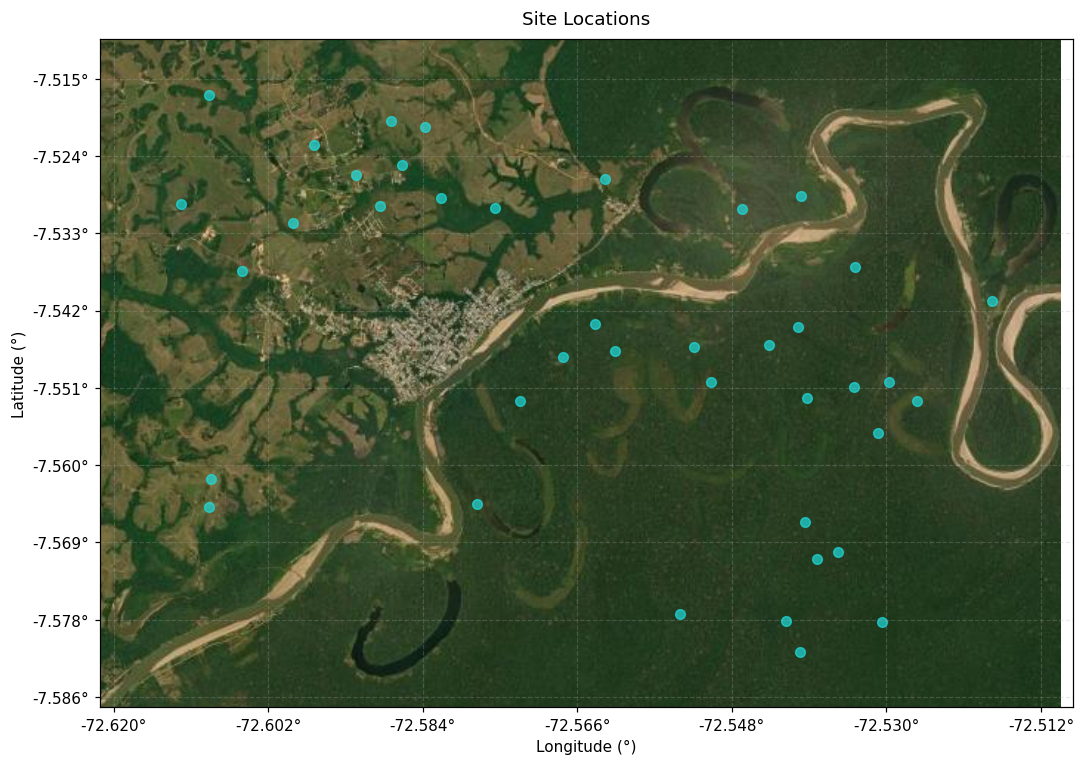

In [5]:
fig, ax = plot_map(df, 
                   basemap='satellite', 
                   alpha=0.7, 
                   color="#1FDBDB", 
                   buffer_pct=0.1,
                   title="Site Locations")  

In [6]:
aoi = create_aoi_from_coordinates(df,
                                  buffer_km=AOI_BUFFER_KM)

📍 AOI Bounds: Lat[-7.8512, -7.2471], Lon[-72.8843, -72.2454]
📊 Defined study area for 40 points with 30km margin.


In [7]:
export_aoi_geojson(aoi=aoi, output_path=OUTPUT_AOI_PATH)

## Extract variables for each site

In [8]:
# Process EII (ecosystem integrity index)
df, images_eii = extract_eii(df=df, aoi=aoi, points_feature_collection=points_fc)
df

2026-01-26 12:31:45,536 - INFO - -----------------------------------------------
2026-01-26 12:31:45,537 - INFO - Starting --Ecosystem Integrity Index (EII)-- extraction...
2026-01-26 12:31:45,538 - INFO - Layers: all
2026-01-26 12:31:45,538 - INFO - Aggregation method: min_fuzzy_logic
2026-01-26 12:31:45,538 - INFO - BII temporal range: 2020-2022
2026-01-26 12:31:45,538 - INFO - Scale: 300m
2026-01-26 12:31:45,539 - INFO - Loading EII layers from Earth Engine...
2026-01-26 12:31:45,540 - INFO - Creating image stack and extracting statistics...
2026-01-26 12:31:45,540 - INFO - Extract statistics for each available band
2026-01-26 12:31:48,745 - INFO - FUNCTIONAL_INTEGRITY mean: 0.684 ± 0.147 (range 0.498-0.889)
2026-01-26 12:31:48,746 - INFO - STRUCTURAL_INTEGRITY mean: 0.824 ± 0.075 (range 0.736-0.965)
2026-01-26 12:31:48,747 - INFO - COMPOSITIONAL_INTEGRITY mean: 0.826 ± 0.106 (range 0.587-0.945)
2026-01-26 12:31:48,747 - INFO - EII mean: 0.657 ± 0.155 (range 0.459-0.887)


,id,latitude,longitude,functional_integrity_mean,functional_integrity_std,structural_integrity_mean,structural_integrity_std,compositional_integrity_mean,compositional_integrity_std,eii_mean,eii_std
0,1,-7.576890,-72.553969,0.860,0.004,0.911,0.016,0.935,0.001,0.855,0.004
1,2,-7.526730,-72.562637,0.620,0.068,0.772,0.005,0.790,0.033,0.590,0.065
2,3,-7.543823,-72.540252,0.851,0.008,0.857,0.006,0.911,0.002,0.839,0.008
3,4,-7.531851,-72.598930,0.545,0.004,0.736,0.000,0.587,0.024,0.486,0.006
4,5,-7.522827,-72.596477,0.505,0.025,0.742,0.002,0.672,0.056,0.463,0.023
5,6,-7.525192,-72.586297,0.533,0.018,0.741,0.003,0.824,0.017,0.509,0.018
6,7,-7.536930,-72.533569,0.689,0.103,0.879,0.003,0.881,0.013,0.680,0.102
7,8,-7.526303,-72.591688,0.522,0.007,0.737,0.001,0.800,0.026,0.494,0.006
8,9,-7.569753,-72.535630,0.849,0.009,0.930,0.009,0.939,0.000,0.846,0.008
9,10,-7.552388,-72.526359,0.689,0.037,0.908,0.005,0.892,0.027,0.682,0.036


In [ ]:
images_eii

In [ ]:
# Process NDVI
df, image_ndvi = extract_ndvi(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    start_date="2025-01-01",
    end_date="2025-12-31",
    scale=30,
    mask_water=True,
    cloud_cover_threshold=50
)
df

In [ ]:
image_ndvi

In [ ]:
df, image_canopy_height = extract_canopy_height(df,
                                                aoi=aoi,
                                                points_feature_collection=points_fc,
                                                scale=10)
df

In [ ]:
df, image_biomass = extract_biomass(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=100,
    year=2022
)
df

In [ ]:
df, image_landcover = extract_landcover(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=10
)
df

In [ ]:
df, image_elevation = extract_elevation(df=df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        scale=30)
df

In [ ]:
df, image_waterdist = extract_distance_to_water(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=30,
    max_search_distance=20_000,
)
df

In [ ]:
df, image_bii = extract_bii(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    year=2020,
    scale=100
)

In [ ]:
df, image_nightlights = extract_nighttime_lights(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=464,
    year=2022
)
df

In [ ]:
# Do not save embeddings images for now
df, _ = extract_satellite_embedding(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    year=2024,
    scale=10
)

In [ ]:
df, image_worldclim = extract_worldclim(df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        variables=['bio01', 'bio02'], # comment/uncomment to select all/specific variables
                                        )
df

## Export results CSV

In [ ]:
export_csv(df, OUTPUT_CSV_PATH)

## Select variables for AOI operations (Raster and HexGrid exports)

In [ ]:
# Select variables that you want to include in the image stack for the rasters and hexgrid exports
image_stack = ee.Image.cat([
    image_ndvi,
    image_canopy_height,
    image_biomass,
    image_landcover,
    image_elevation,
    image_waterdist,
    image_bii,
    image_nightlights,
    image_worldclim,
])

Plot any raster before any exporting if you want to double check them

In [ ]:
map = plot_images(image_stack,
                  aoi=aoi,
                  points_fc=points_fc,
                  zoom=10,
                  scale=30,
                  filter_bands=['canopy_height'],
                  )
map

## Export raw rasters

In [ ]:
# Uncomment to export raw rasters
export_rasters_to_gdrive(
   image=image_stack,
   region=aoi,
   scale=100,
   crs="EPSG:4326",
   file_format="GeoTIFF",
   #    file_name_prefix="2025"
)

## Creating hexagon and extraction values

Select images or bands to extract values for hexagons

In [ ]:

image_stack = ee.Image.cat([
    image_ndvi,
    image_canopy_height,
    image_biomass,
    image_landcover,
    image_elevation,
    image_waterdist.select('distance_to_water_m'), # drop water mask
    image_bii,
    image_nightlights,
    image_worldclim,
])

In [ ]:
hex_gdf = generate_h3_hexagon_grid(aoi=aoi,
                                   h3_resolution=HEXAGRID_RESOLUTION,
                                   crs="EPSG:4326")
hex_gdf

In [ ]:
hexagons_with_data = extract_values_from_hexagons(
    hex_gdf=hex_gdf,
    image_stack=image_stack,
    batch_size=100, 
    tileScale=4, # increase up to 16 if having memory issues
)

**Check results for hexagons**

In [ ]:
hexagons_with_data

In [ ]:
hexagons_with_data.plot(column='ndvi', legend=False, cmap='viridis', figsize=(10, 8))


In [ ]:
export_hexagrid_results(hexagons_with_data, output_path=OUTPUT_HEXAGRID_PATH)

___